In [1]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

try:
    # 1. Chargement des données de test
    data = joblib.load('processed_data.pkl')
    X_test = data['X_test']
    y_test = data['y_test']

    # 2. Chargement des modèles
    model_lr = joblib.load('model_lr.pkl') # Le modèle linéaire
    model_dt = joblib.load('model_dt.pkl') # L'arbre de décision

    print(f"✅ Données chargées. Taille du test set : {X_test.shape[0]} vols.")
    print(f"✅ Modèles 'model_lr.pkl' et 'model_dt.pkl' chargés.")

except FileNotFoundError as e:
    print(f"❌ ERREUR : Fichier manquant ({e}). Avez-vous fini l'étape 3 ?")

✅ Données chargées. Taille du test set : 19704 vols.
✅ Modèles 'model_lr.pkl' et 'model_dt.pkl' chargés.



-> Rapport de Classification :
              precision    recall  f1-score   support

           0       0.87      0.61      0.72     16193
           1       0.25      0.60      0.35      3511

    accuracy                           0.61     19704
   macro avg       0.56      0.60      0.54     19704
weighted avg       0.76      0.61      0.65     19704



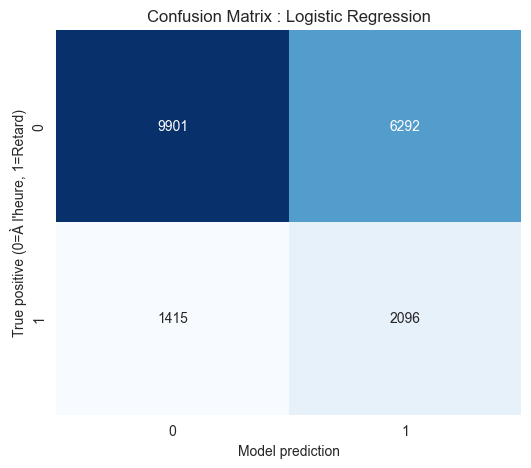

In [3]:
# 1. Prédictions
y_pred_lr = model_lr.predict(X_test)

# 2. Rapport Détaillé (Précision, Rappel, F1)
print("\n-> Rapport de Classification :")
print(classification_report(y_test, y_pred_lr))

# 3. Matrice de Confusion (Visuelle)
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix : Logistic Regression')
plt.ylabel('True positive (0=À l\'heure, 1=Retard)')
plt.xlabel('Model prediction')
plt.show()


-> Rapport de Classification :
              precision    recall  f1-score   support

           0       0.83      0.87      0.85     16193
           1       0.25      0.20      0.22      3511

    accuracy                           0.75     19704
   macro avg       0.54      0.54      0.54     19704
weighted avg       0.73      0.75      0.74     19704



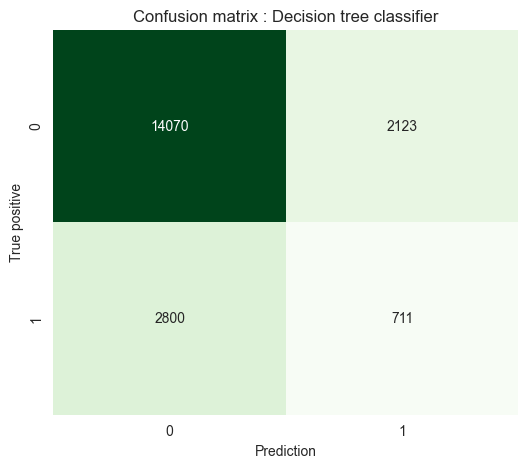

In [6]:
# 1. Prédictions
y_pred_dt = model_dt.predict(X_test)

# 2. Rapport Détaillé
print("\n-> Rapport de Classification :")
print(classification_report(y_test, y_pred_dt))

# 3. Matrice de Confusion
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion matrix : Decision tree classifier')
plt.ylabel('True positive')
plt.xlabel('Prediction')
plt.show()

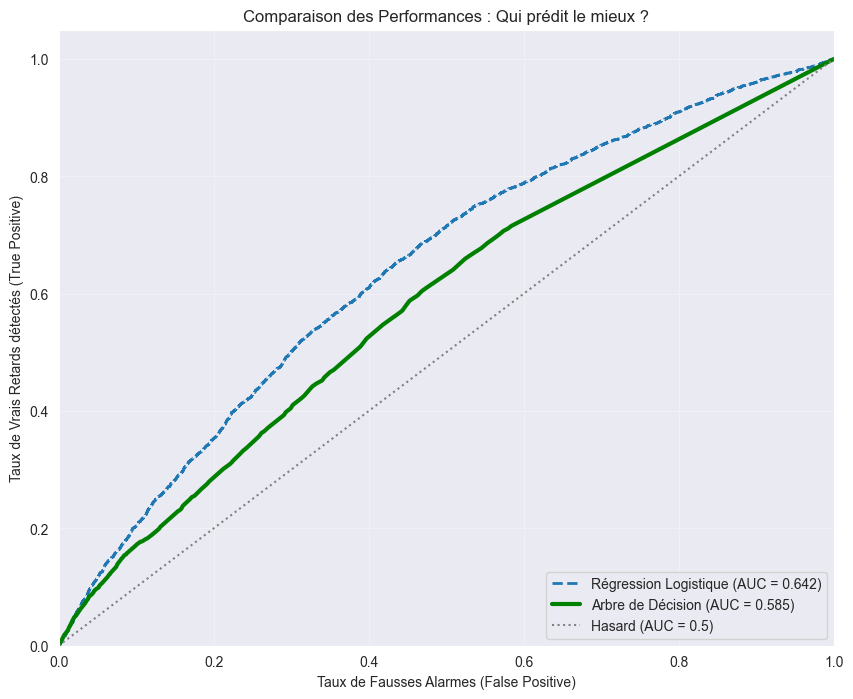


--- End of Project ---


In [8]:
plt.figure(figsize=(10, 8))

# --- Modèle 1 : Régression Logistique ---
# On récupère les probabilités (pas juste 0 ou 1) pour tracer la courbe
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, linestyle='--', lw=2, label=f'Régression Logistique (AUC = {auc_lr:.3f})')

# --- Modèle 2 : Arbre de Décision ---
y_prob_dt = model_dt.predict_proba(X_test)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, lw=3, color='green', label=f'Arbre de Décision (AUC = {auc_dt:.3f})')

# --- Mise en forme ---
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Hasard (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Fausses Alarmes (False Positive)')
plt.ylabel('Taux de Vrais Retards détectés (True Positive)')
plt.title('Comparaison des Performances : Qui prédit le mieux ?')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print("\n--- End of Project ---")